# Import packages and load data

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from matplotlib import rc
from matplotlib import cm
from matplotlib import rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes  
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)  
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
import shap
from joblib import dump, load
xscaler = MinMaxScaler()

In [2]:
file_path = '../../pre-processing/likeness_data/repeat_rdkit_physchem.xlsx'
output = 'gisaxs_fwhm'
output_path = f'./final_figs/{output}_bayesian/shap/'
# import data frame for pre-processing
df = pd.read_excel(file_path)
df.head()

,Sample,comp1_blockA_type_comp1_blockB_type_likeness,comp1_blockA_type_comp1_blockB_type_exists,comp1_blockA_type_comp2_blockA_type_likeness,comp1_blockA_type_comp2_blockA_type_exists,comp1_blockA_type_comp2_blockB_type_likeness,comp1_blockA_type_comp2_blockB_type_exists,comp1_blockA_type_add_type_likeness,comp1_blockA_type_add_type_exists,comp1_blockA_type_solv_1_likeness,...,solv_1_solv_2_exists,comp1_frac,solv_ratio,add_ratio,comp1_blockA_MW,comp1_blockB_MW,comp2_blockA_MW,comp2_blockB_MW,gisaxs_domain,gisaxs_fwhm
0,I_A_AC,0.706298,1,0.0,0,0.0,0,0.865831,1,0.985532,...,1,1.0,0.8,1.00,23.0,7.0,0.0,0.0,31.302630,0.003697
1,I_A025,0.706298,1,0.0,0,0.0,0,0.865831,1,0.985532,...,1,1.0,0.8,1.25,23.0,7.0,0.0,0.0,33.805848,0.003136
2,I_A050,0.706298,1,0.0,0,0.0,0,0.865831,1,0.985532,...,1,1.0,0.8,1.50,23.0,7.0,0.0,0.0,34.176062,0.002970
3,I_A075,0.706298,1,0.0,0,0.0,0,0.865831,1,0.985532,...,1,1.0,0.8,1.75,23.0,7.0,0.0,0.0,34.383751,0.003451
4,I_A_100,0.706298,1,0.0,0,0.0,0,0.865831,1,0.985532,...,1,1.0,0.8,2.00,23.0,7.0,0.0,0.0,31.674148,0.005122


# Data pre-processing

In [3]:
best = load(f'raw_models/bayesian/fwhm/scaled_{output}_repeat_rdkit_physchem.joblib')

# Drop any samples with missing data
df_clean = df.dropna()

# Assign input variables and target variable
inputs = df_clean.iloc[:, 1:-2].copy()
target = df_clean[f'{output}']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    inputs, target, test_size=0.2, random_state=10
)

# Scale the inputs (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

y_train_pred = best.predict(X_train_scaled)
y_test_pred = best.predict(X_test_scaled)

X_all = pd.concat([X_train_scaled, X_test_scaled], ignore_index=True)
y_all = np.concatenate([y_train, y_test])
y_all_pred = best.predict(X_all)

train_r2 = best.score(X_train_scaled, y_train)
test_r2 = best.score(X_test_scaled, y_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f'Training r2: {train_r2}, training mae: {train_mae}')
print(f'Testing r2: {test_r2}, testing mae: {test_mae}')

Training r2: 0.9139118450520651, training mae: 0.0002569007524297392
Testing r2: 0.8347624631916717, testing mae: 0.0003848397949875332


# SHAP Analysis

In [4]:
%matplotlib inline
rc('text', usetex=False)
rc('mathtext', fontset='cm')
rc('xtick', labelsize=25)   
rc('xtick.major', size=7)  
rc('xtick.minor', size=4)
rc('xtick.major', width=2)
rc('xtick.minor', width=2)
rc('ytick.major', width=2)
rc('ytick.minor', width=2)
rc('ytick', labelsize=25)
rc('ytick.major', size=7)
rc('ytick.minor', size=4)
rc('axes', labelsize=25) 
rc('axes', linewidth=2) 
rc('font',family='sans serif')
rc('font', style='normal')
rc('font', weight='500')
rc('font', size='15')
rc('axes', labelweight='500')
rc('axes.spines', **{'right':True, 'top':True}) 
plt.rcParams['font.family'] = 'Arial'

In [12]:
# # === CUSTOM LABELS for top N features (in ranked order, best to worst) ===
# # Set to None to use original names, or provide a list of exactly top_n strings:
# #   custom_labels = ['Best Feature', '2nd Best', '3rd Best', ...]
# custom_labels = None 

# # custom_labels = ['Additive Ratio', 'C1-B/Solv.-1 Likeness', 'C1-B/Add. Likeness', 'C1-A/C1-B Likeness',
# #                  'C1-B MW', 'C1-A MW', 'C1-B/Solv.-2 Likeness', 'C1-A/Add. Likeness']

# # Initialize the explainer
# explainer = shap.Explainer(best, X_train_scaled)
# # Calculate SHAP values for the test set
# shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)
# # Calculate average absolute SHAP values per feature
# avg_shap_per_feature = np.abs(shap_values).mean(axis=0)

# # === NORMALIZE so cumulative sum = 1 ===
# avg_shap_per_feature = avg_shap_per_feature / avg_shap_per_feature.sum()

# # Automatically get feature names
# if hasattr(X_train_scaled, 'columns'):
#     features_r = X_train_scaled.columns.tolist()
# else:
#     features_r = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

# # Sort by average SHAP magnitude
# sorted_indices = np.argsort(avg_shap_per_feature)[::-1]
# avg_shap_sorted = avg_shap_per_feature[sorted_indices]
# features_sorted = [features_r[i] for i in sorted_indices]

# # Limit to top N features
# top_n = 10
# features_sorted = features_sorted[:top_n]
# avg_shap_sorted = avg_shap_sorted[:top_n]

# # === Apply custom labels to top N after slicing ===
# if custom_labels is not None:
#     if len(custom_labels) != top_n:
#         raise ValueError(f"custom_labels must have exactly {top_n} entries, got {len(custom_labels)}")
#     features_sorted = custom_labels

In [5]:
# === CUSTOM LABELS for top N features (in ranked order, best to worst) ===
custom_labels = None  # <-- Edit this
# custom_labels = ['C1-A MW', 'C1-B MW', 'Additive Ratio', 'C1 Fraction', 'C1-B/Add. Likeness',
#                  'C1-A/C1-B Likeness', 'C1-B/Solv.-1 Likeness', 'C2-B MW', 'C1-B/Solv.-2 Likeness', 
#                  'C2-A/C2-B Likeness']
custom_labels = ['Additive Ratio', 'C1-A/C1-B Similarity', 'C1-B/Solv.-1 Similarity',
                 'C1-B/Add. Similarity', 'C1-A MW', 'C1-B MW', 
                 'C1-B/Solv.-2 Similarity', 'C1 Fraction']

# Initialize the explainer
explainer = shap.Explainer(best, X_train_scaled)
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)
# Calculate average absolute SHAP values per feature
avg_shap_per_feature = np.abs(shap_values).mean(axis=0)
# === NORMALIZE so cumulative sum = 1 ===
avg_shap_per_feature = avg_shap_per_feature / avg_shap_per_feature.sum()

# Automatically get feature names
if hasattr(X_train_scaled, 'columns'):
    features_r = X_train_scaled.columns.tolist()
else:
    features_r = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

# === CUMULATIVE SHAP % FOR 'likeness' FEATURES ===
likeness_mask = [('likeness' in f.lower()) for f in features_r]
likeness_shap_total = avg_shap_per_feature[np.array(likeness_mask)].sum()
likeness_features = [(features_r[i], avg_shap_per_feature[i]) for i, m in enumerate(likeness_mask) if m]
likeness_features_sorted = sorted(likeness_features, key=lambda x: x[1], reverse=True)

print("=" * 50)
print("SHAP Contribution — 'Likeness' Features")
print("=" * 50)
for fname, shap_val in likeness_features_sorted:
    print(f"  {fname:<40s}  {shap_val * 100:6.2f}%")
print("-" * 50)
print(f"  {'CUMULATIVE TOTAL':<40s}  {likeness_shap_total * 100:6.2f}%")
print("=" * 50)
# =====================================================

# Sort by average SHAP magnitude
sorted_indices = np.argsort(avg_shap_per_feature)[::-1]
avg_shap_sorted = avg_shap_per_feature[sorted_indices]
features_sorted = [features_r[i] for i in sorted_indices]
# Limit to top N features
top_n = 8
features_sorted = features_sorted[:top_n]
avg_shap_sorted = avg_shap_sorted[:top_n]
# === Apply custom labels to top N after slicing ===
if custom_labels is not None:
    if len(custom_labels) != top_n:
        raise ValueError(f"custom_labels must have exactly {top_n} entries, got {len(custom_labels)}")
    features_sorted = custom_labels

SHAP Contribution — 'Likeness' Features
  comp1_blockA_type_comp1_blockB_type_likeness   10.70%
  comp1_blockB_type_solv_1_likeness           9.67%
  comp1_blockB_type_add_type_likeness         9.31%
  comp1_blockB_type_solv_2_likeness           3.57%
  add_type_solv_1_likeness                    1.73%
  comp1_blockA_type_add_type_likeness         1.48%
  add_type_solv_2_likeness                    1.05%
  comp2_blockB_type_solv_1_likeness           0.48%
  comp2_blockB_type_solv_2_likeness           0.44%
  comp2_blockA_type_comp2_blockB_type_likeness    0.39%
  comp1_blockA_type_comp2_blockA_type_likeness    0.33%
  comp1_blockA_type_comp2_blockB_type_likeness    0.31%
  comp1_blockB_type_comp2_blockA_type_likeness    0.30%
  comp2_blockB_type_add_type_likeness         0.28%
  comp1_blockB_type_comp2_blockB_type_likeness    0.24%
  comp2_blockA_type_solv_1_likeness           0.22%
  comp2_blockA_type_add_type_likeness         0.22%
  comp2_blockA_type_solv_2_likeness           0.15%


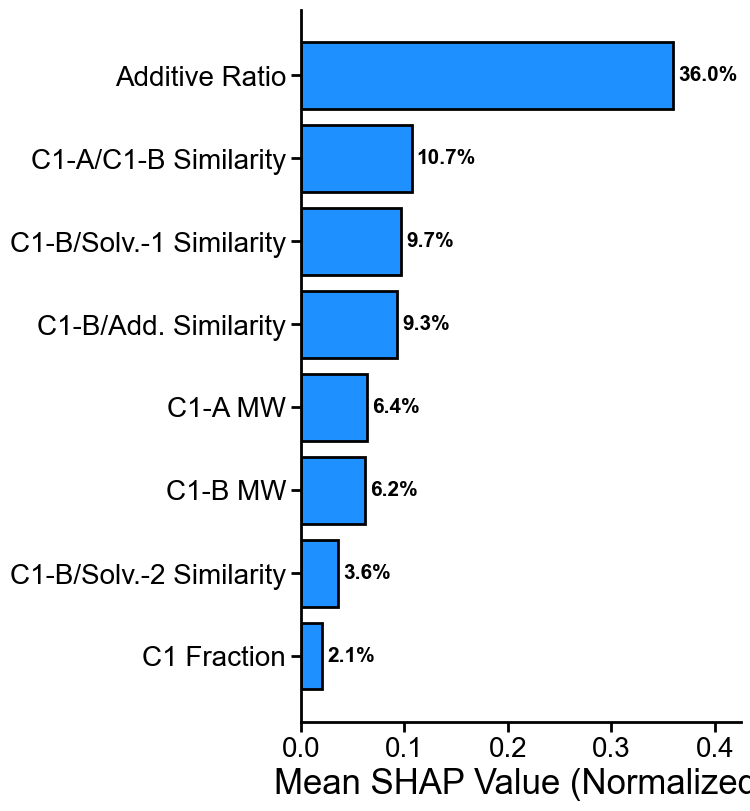

In [18]:
# Define the figure title
fig_title = 'shap_global.pdf'

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
y_positions = np.arange(len(features_sorted))
ax.barh(y_positions, avg_shap_sorted, color='dodgerblue', edgecolor='black', linewidth=2)
ax.set_yticks(y_positions)
ax.set_yticklabels(features_sorted, fontsize=20)
ax.invert_yaxis()
ax.set_xlabel('Mean SHAP Value (Normalized)', fontsize=25)
ax.tick_params(axis='x', labelsize=20)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.set_xlim(0, 0.425)

# Add value labels next to each bar
for i, val in enumerate(avg_shap_sorted):
    ax.text(val + 0.005, i, f'{val:.1%}', va='center', fontweight='bold', fontsize=15)

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.tight_layout()
plt.subplots_adjust(left=0.4, right=0.95, top=0.99, bottom=0.1)
ax.set_facecolor('none')  # Sets the plotting area to transparent
fig.patch.set_alpha(0.0)  # Ensures the figure background has 0 opacity
plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.show()

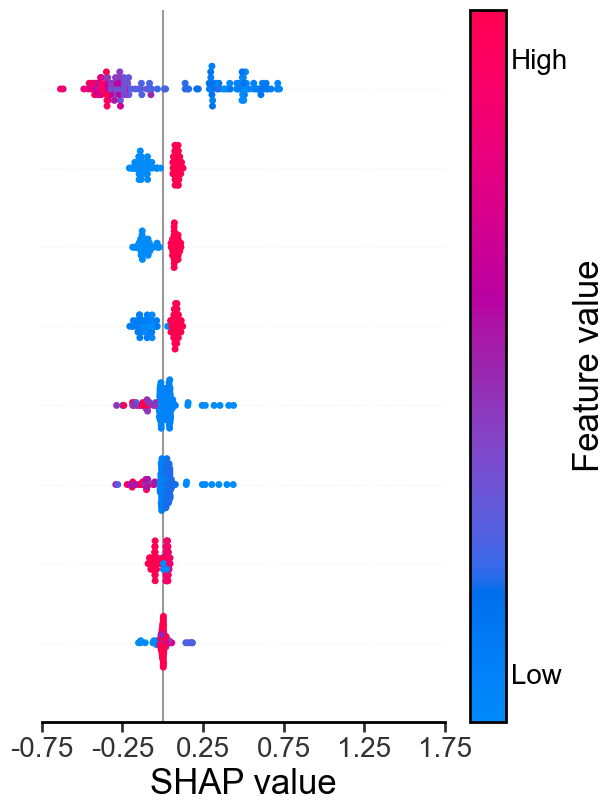

In [17]:
# Define figure title
fig_title = 'shap_local.pdf'

show_feature_names = False

# Automatically get feature names
if hasattr(X_train_scaled, 'columns'):
    feature_names = X_train_scaled.columns.tolist()
else:
    feature_names = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

normalizer = np.abs(shap_values).mean(axis=0).sum()
shap_values_normalized = shap_values / normalizer

# Create the SHAP summary plot
plt.figure(figsize=(6, 8))
shap.summary_plot(
    shap_values_normalized,
    X_test_scaled,
    feature_names=feature_names,
    max_display=8,
    show=False,
    color_bar=False,
    plot_size=None
)

# Remove feature names if toggle is off
if not show_feature_names:
    ax = plt.gca()
    ax.set_yticklabels([])
    ax.set_ylabel('')  # remove "Feature" label if SHAP adds it
    
# Add and customize the colorbar
cbar = plt.colorbar()
cbar.set_label('Feature value', fontsize=25, wrap=True)
cbar.ax.tick_params(labelsize=20)

# Customize the colorbar ticks to show 'high' and 'low'
cbar.set_ticks([-1, 1.55])
cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(direction='out', length=0, width=0, grid_alpha=0.5)

# Set labels and ticks
plt.xlabel('SHAP value', fontsize=25)
plt.xticks(fontsize=20)
# ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
ax.xaxis.offsetText.set_fontsize(20)

# plt.tight_layout()
plt.subplots_adjust(left=0.06, right=0.9, top=0.99, bottom=0.1)

ax = plt.gca()
# Use plain formatting and turn off the offset
ax.ticklabel_format(useOffset=False, style='plain', axis='x')

# Re-apply the fontsize just to be sure
plt.xticks(fontsize=20)

# Get current limits to ensure all ticks are covered
xmin, xmax = ax.get_xlim()

# Generate ticks from the start to end in 0.25 steps
# Adding a small buffer to xmax ensures the final tick is included
# custom_ticks = np.arange(np.floor(xmin*4)/4, xmax + 0.01, 0.5)
custom_ticks = np.arange(-0.75, 1.76, 0.5)

ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x:.2f}' for x in custom_ticks], fontsize=20)

# Save and show
# plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.savefig(output_path + fig_title, format='pdf', transparent=True)
plt.show()

TypeError: summary_legacy() got an unexpected keyword argument 'ax'

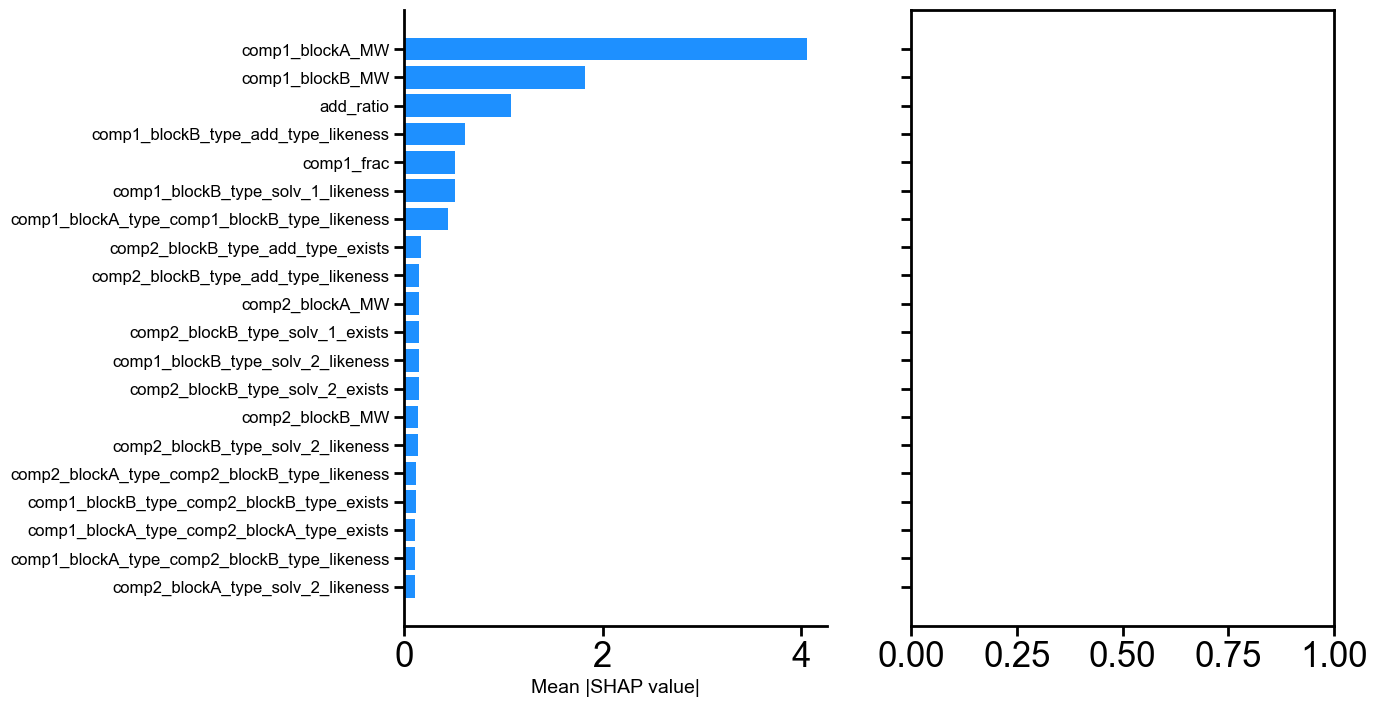

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# --- Sort and subset features ---
avg_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(avg_shap)[::-1]
top_n = 20
sorted_idx = sorted_idx[:top_n]

if hasattr(X_train_scaled, 'columns'):
    feature_names = X_train_scaled.columns.tolist()
else:
    feature_names = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

features_sorted = [feature_names[i] for i in sorted_idx]
avg_shap_sorted = avg_shap[sorted_idx]

# --- Create shared-y layout ---
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(12, 8),
    gridspec_kw={'width_ratios': [1, 1]},
    sharey=True
)

# --- Left: Mean SHAP (global bar plot) ---
y_positions = np.arange(len(features_sorted))
ax1.barh(y_positions, avg_shap_sorted, color='dodgerblue')
ax1.set_yticks(y_positions)
ax1.set_yticklabels(features_sorted, fontsize=12)
ax1.invert_yaxis()
ax1.set_xlabel('Mean |SHAP value|', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right: SHAP summary (local values) ---
# SHAP will plot directly into ax2
shap.summary_plot(
    shap_values[:, sorted_idx],
    X_test_scaled.iloc[:, sorted_idx] if hasattr(X_test_scaled, 'iloc') else X_test_scaled[:, sorted_idx],
    feature_names=[feature_names[i] for i in sorted_idx],
    show=False,
    color_bar=True,
    plot_size=None,
    ax=ax2
)

# Hide redundant feature labels on right
ax2.set_yticklabels([])
ax2.set_ylabel('')
ax2.set_xlabel('SHAP value', fontsize=14)

# Align and clean layout
plt.tight_layout()
plt.show()

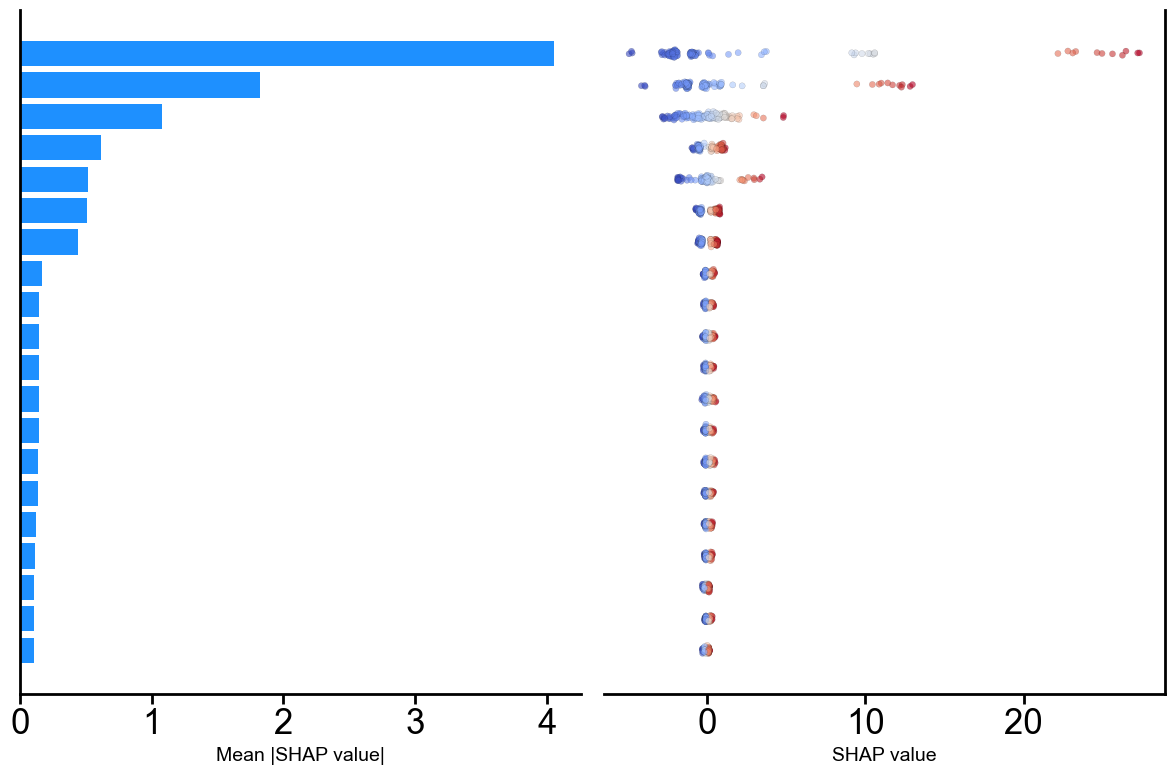

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features
avg_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(avg_shap)[::-1]
top_n = 20
sorted_idx = sorted_idx[:top_n]

if hasattr(X_train_scaled, 'columns'):
    feature_names = X_train_scaled.columns.tolist()
else:
    feature_names = [f'Feature {i+1}' for i in range(X_train_scaled.shape[1])]

features_sorted = [feature_names[i] for i in sorted_idx]
avg_shap_sorted = avg_shap[sorted_idx]

# Shared y-axis figure
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(12, 8), gridspec_kw={'width_ratios': [1, 1]}, sharey=True
)

# Left: mean SHAP
y_positions = np.arange(len(features_sorted))
ax1.barh(y_positions, avg_shap_sorted, color='dodgerblue')
ax1.set_yticks(y_positions)
ax1.set_yticklabels(features_sorted, fontsize=12)
ax1.invert_yaxis()
ax1.set_xlabel('Mean |SHAP value|', fontsize=14)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: manual “local SHAP” scatter
for i, idx in enumerate(sorted_idx):
    y = np.random.normal(i, 0.05, size=shap_values.shape[0])  # jitter
    x = shap_values[:, idx]
    ax2.scatter(x, y, alpha=0.6, s=20, c=x, cmap='coolwarm', edgecolor='k', linewidth=0.1)

ax2.set_yticks([])
ax2.set_ylabel('')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.set_xlabel('SHAP value', fontsize=14)

plt.tight_layout()
plt.show()


In [31]:
# Features ['Solvent ratio','Swelling ratio', 'Additive type']

# Remove the second column
swell_add_shap = np.delete(shap_values, 0, axis=1)
solv_add_shap = np.delete(shap_values, 1, axis=1)
solv_swell_shap = np.delete(shap_values, 2, axis=1)

In [32]:
# Features ['Solvent ratio','Swelling ratio', 'Additive type']

full_set_inv = xscaler.inverse_transform(full_set)

# Remove the second column
swell_add_x = np.delete(full_set_inv, 0, axis=1)
solv_add_x = np.delete(full_set_inv, 1, axis=1)
solv_swell_x = np.delete(full_set_inv, 2, axis=1)

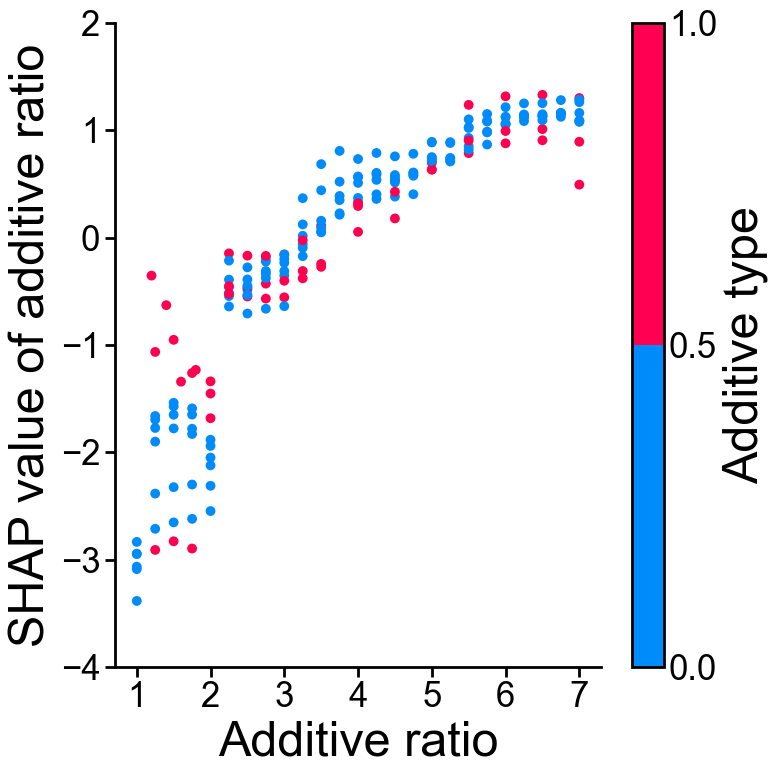

In [33]:
# Define the figure title
fig_title = 'shap/swell_add_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[1], features[2]]
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, swell_add_shap, swell_add_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel('Additive ratio', fontsize=35)
plt.ylabel('SHAP value of additive ratio', fontsize=35, wrap=True)
plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure

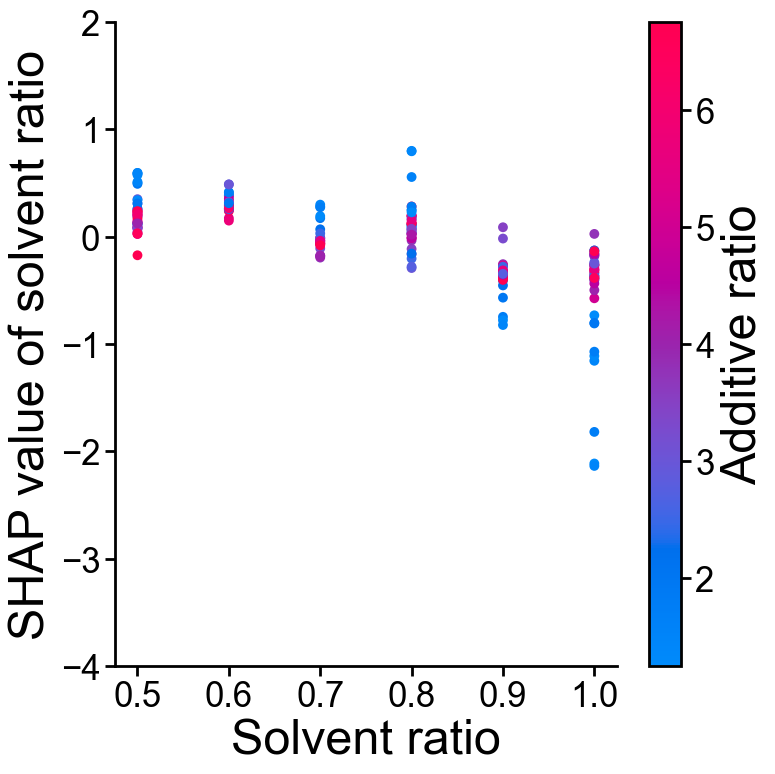

In [15]:
# Define the figure title
fig_title = 'shap/solv_swell_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[0], features[1]]
# print(features)
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, solv_swell_shap, solv_swell_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel('Solvent ratio', fontsize=35)
plt.ylabel('SHAP value of solvent ratio', fontsize=35, wrap=True)
plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure

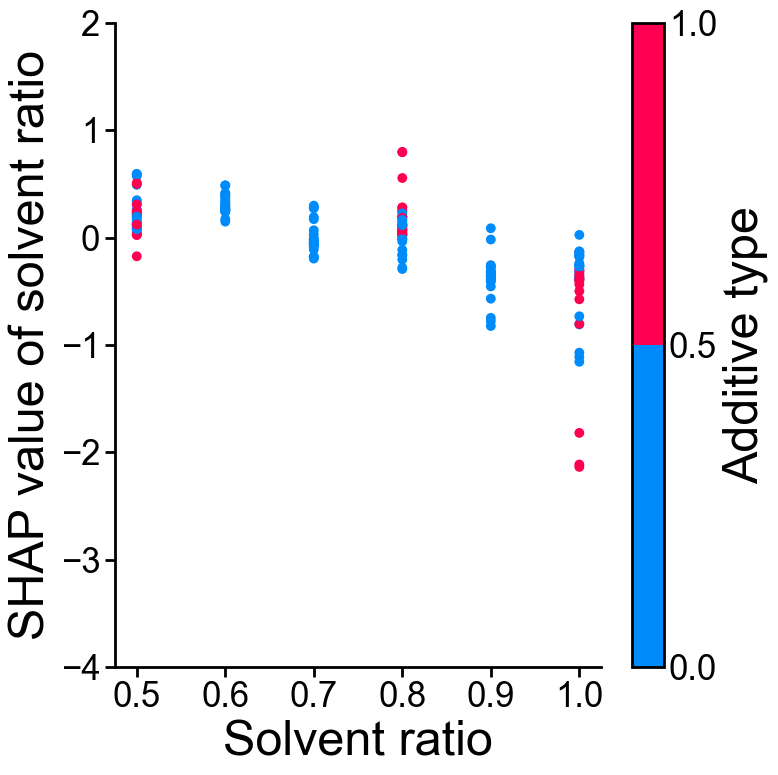

In [16]:
# Define the figure title
fig_title = 'shap/solv_add_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[0], features[2]]
# print(features)
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, solv_add_shap, solv_add_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel('Solvent ratio', fontsize=35)
plt.ylabel('SHAP value of solvent ratio', fontsize=35, wrap=True)
plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure

# Switch columns

In [17]:
# Creating a list of indices for reordering columns
i = [1, 0]

# Reorder the columns for new plots
add_swell_shap = swell_add_shap[:, i]
add_solv_shap = solv_add_shap[:, i]
swell_solv_shap = solv_swell_shap[:, i]

# Reorder the columns for new plots
add_swell_x = swell_add_x[:, i]
add_solv_x = solv_add_x[:, i]
swell_solv_x = solv_swell_x[:, i]

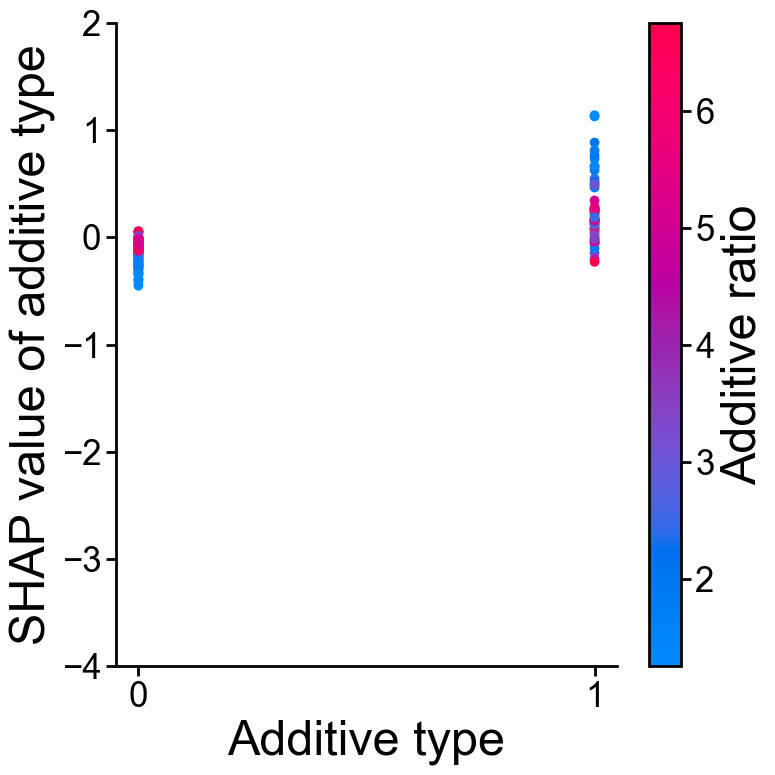

In [34]:
# Define the figure title
fig_title = 'shap/add_swell_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[2], features[1]]
# print(features)
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, add_swell_shap, add_swell_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel(feature_name, fontsize=35)
plt.ylabel('SHAP value of additive type', fontsize=35, wrap=True)
plt.xticks([0, 1], fontsize=25)  # <-- Only show ticks at 0 and 1
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure

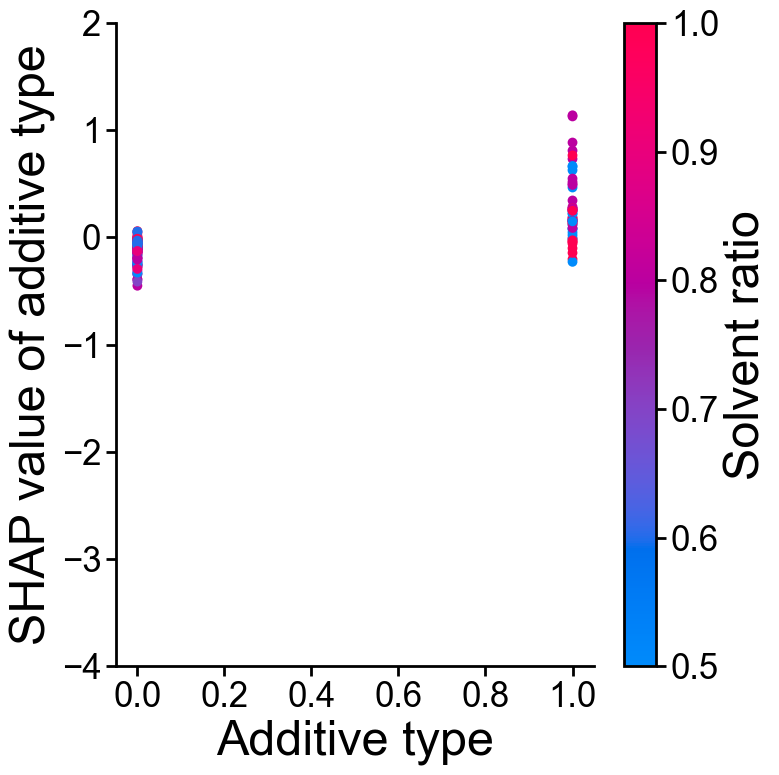

In [19]:
# Define the figure title
fig_title = 'shap/add_solv_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[2], features[0]]
# print(features)
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, add_solv_shap, add_solv_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel(feature_name, fontsize=35)
plt.ylabel('SHAP value of additive type', fontsize=35, wrap=True)
plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure

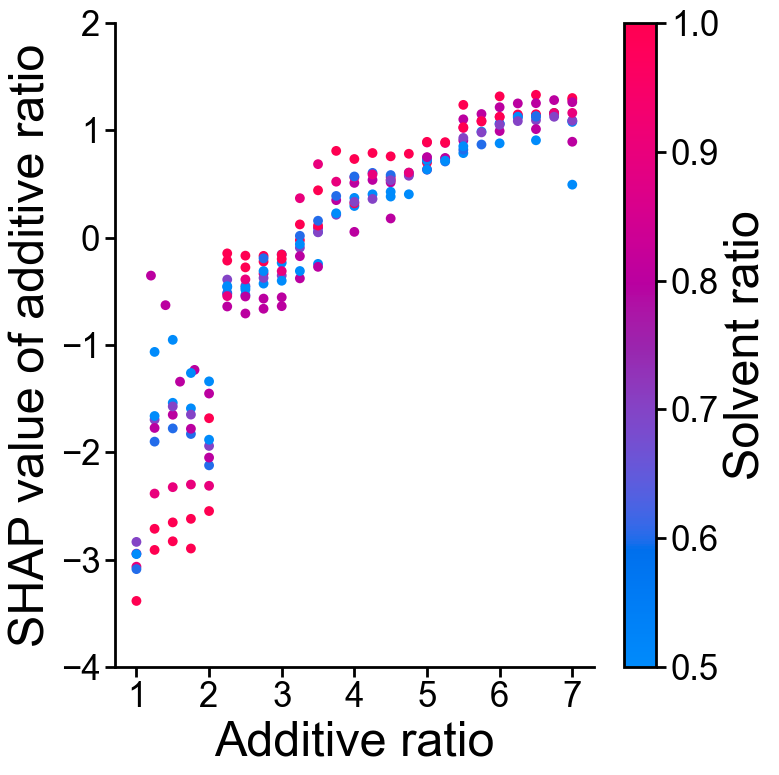

In [20]:
# Define the figure title
fig_title = 'shap/swell_solv_shap'

features = ['Solvent ratio','Additive ratio', 'Additive type']
features = [features[1], features[0]]
# print(features)
feature_name = features[0]
# Plot the SHAP values
shap_figure = shap.dependence_plot(feature_name, swell_solv_shap, swell_solv_x, feature_names=features, show=False,
                                  dot_size=50)
plt.xlabel(feature_name, fontsize=35)
plt.ylabel('SHAP value of additive ratio', fontsize=35, wrap=True)
plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)
plt.ylim(-4, 2)
plt.tight_layout()
plt.savefig(output_path + fig_title, format='pdf')
shap_figure